In [1]:
import os
import sys 

notebook_path = os.getcwd()
sys.path.insert(0, os.path.dirname(notebook_path))

# current_file = os.path.abspath(__file__)
# grandparent_dir = os.path.dirname(os.path.dirname(current_file))
# sys.path.insert(0, grandparent_dir)


import torch
import torch.nn.functional as F
from torch.nn import Linear
from torch_geometric.nn import GCNConv
from torch_geometric.utils import from_networkx, negative_sampling
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import pandas as pd
import numpy as np 

from syn_real.syn_datagen import analyze_automorphisms

/home/ka/ka_aifb/ka_cc7738/miniconda3/envs/EAsF/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def lobster(N, seed):
    """ Creates a random Lobster graph with a backbone of size b (drawn from U[1, N)), and p (drawn
        from U[1, N − b ]) pendent vertices uniformly connected to the backbone, and additional
        N − b − p pendent vertices uniformly connected to the previous pendent vertices """
    np.random.seed(seed)
    B = np.random.randint(low=1, high=N)
    F = np.random.randint(low=B + 1, high=N + 1)
    G = nx.empty_graph(N)
    for i in range(1, B):
        G.add_edge(i - 1, i)
    for i in range(B, F):
        G.add_edge(i, np.random.randint(B))
    for i in range(F, N):
        G.add_edge(i, np.random.randint(low=B, high=F))

    for n in G.nodes():
        G.nodes[n]['x'] = [1.0]
    
    pyg_data = from_networkx(G)
    auto_edges = []
    auto_nodes = []

    (num_automorphic_edges, 
    num_non_automorphic_edges, 
    non_automorphic_edges, 
    auto_edges, 
    auto_nodes, 
    unique_group_nodes) = analyze_automorphisms(pyg_data, G) # classify edges to be automorphic or not

    return pyg_data, auto_edges, auto_nodes, G

In [3]:
class GCN(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        return self.conv2(x, edge_index)

class LinkPredictor(torch.nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.lin = Linear(2 * dim, 1)

    def forward(self, x_i, x_j):
        return torch.sigmoid(self.lin(torch.cat([x_i, x_j], dim=-1))).squeeze(-1)

In [4]:
def run(N):
    data, auto_edges, auto_nodes, G_nx = lobster(N, 0)
    edge_index = data.edge_index
    data.x = torch.tensor([d['x'] for _, d in G_nx.nodes(data=True)], dtype=torch.float)

    model = GCN(1, 16)
    predictor = LinkPredictor(16)
    optimizer = torch.optim.Adam(list(model.parameters()) + list(predictor.parameters()), lr=0.01)

    neg_edge_index = negative_sampling(edge_index, data.num_nodes, edge_index.size(1))
    all_edge_index = torch.cat([edge_index, neg_edge_index], dim=1)
    labels = torch.cat([torch.ones(edge_index.size(1)), torch.zeros(neg_edge_index.size(1))])

    for _ in range(100):
        model.train()
        x = model(data.x, edge_index)
        src, dst = all_edge_index
        pred = predictor(x[src], x[dst])
        loss = F.binary_cross_entropy(pred, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    model.eval()
    x = model(data.x, edge_index).detach()

    tsne = TSNE(n_components=2, perplexity=2,random_state=0)
    x_2d = tsne.fit_transform(x.numpy())

    # Plot node embeddings
    plt.figure(figsize=(8,6))
    for i, (x_, y_) in enumerate(x_2d):
        color = 'red' if i in auto_nodes else 'blue'
        plt.scatter(x_, y_, c=color)
        plt.text(x_ + 0.02, y_ + 0.02, str(i), fontsize=9)
    plt.title("2D Visualization of Node Embeddings")
    plt.show()


    pos = nx.spring_layout(G_nx, seed=42)
    node_colors = ['green' if n in auto_nodes else 'blue' for n in G_nx.nodes()]
    plt.figure(figsize=(6,6))
    nx.draw(G_nx, pos, with_labels=True, node_color=node_colors, node_size=100)
    plt.title("Original Graph (Red = Automorphic Nodes)")
    plt.show()


    preds, types = [], []
    for i in range(all_edge_index.shape[1]):
        s, d = int(all_edge_index[0, i]), int(all_edge_index[1, i])
        pred = predictor(x[s].unsqueeze(0), x[d].unsqueeze(0)).item()
        t = 'A' if (s,d) in auto_edges or (d,s) in auto_edges else 'NA'
        preds.append(pred)
        types.append(t)

    df = pd.DataFrame({"Prediction": preds, "EdgeType": types})
    df.boxplot(column="Prediction", by="EdgeType")
    plt.title("Link Prediction Score by Edge Type")
    plt.suptitle("")
    plt.ylabel("Score")
    plt.show()

Number of unique-orbit nodes: 18
Distinguishable edges: 0.81
non-automorphic edges: 324
automorphic edges: 76


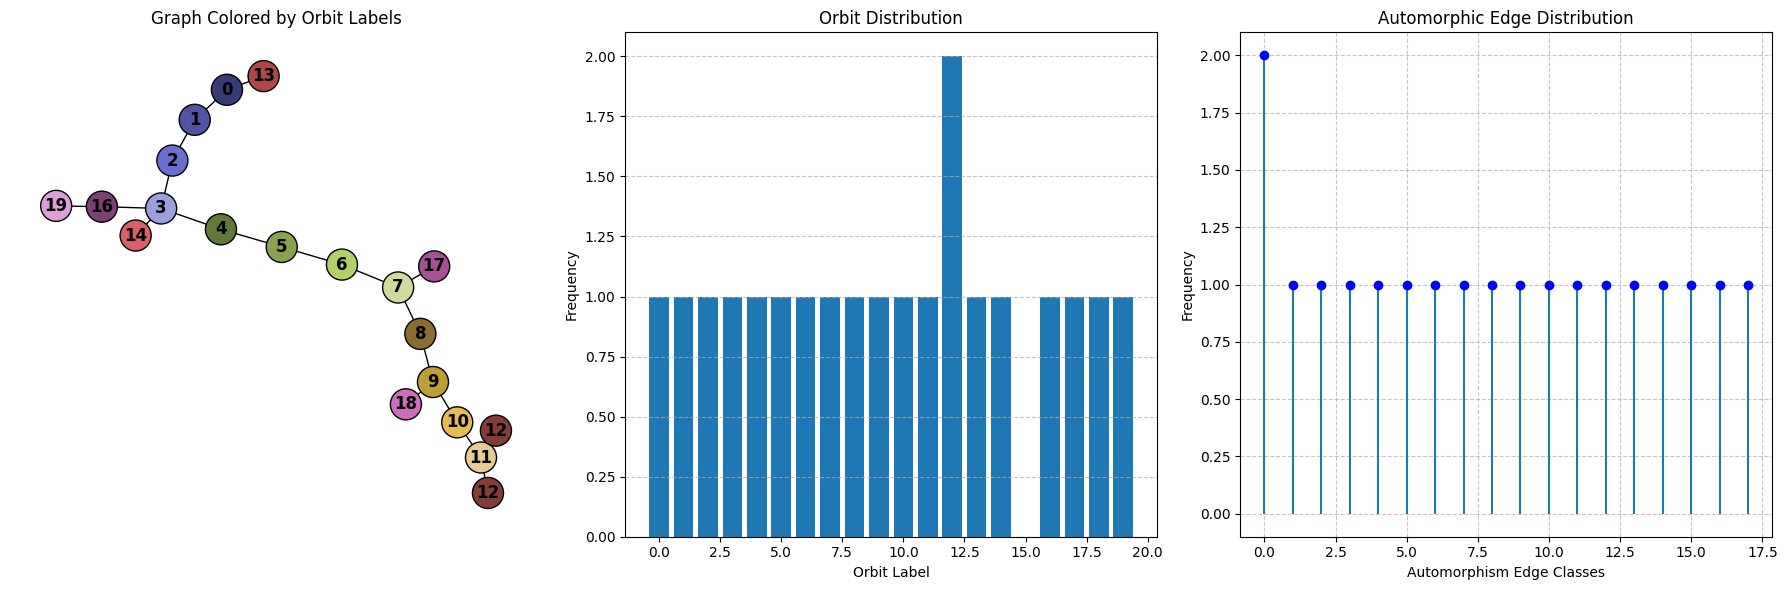

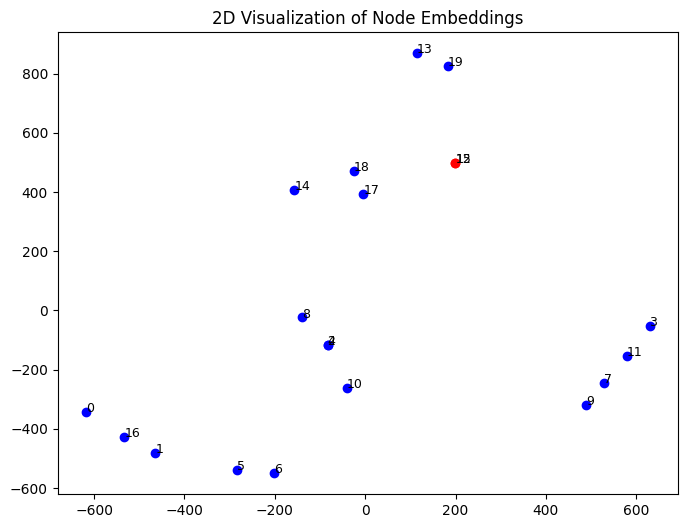

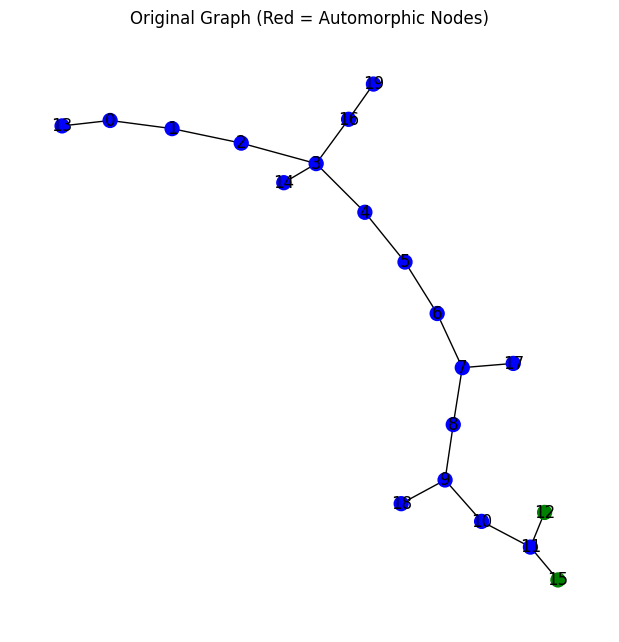

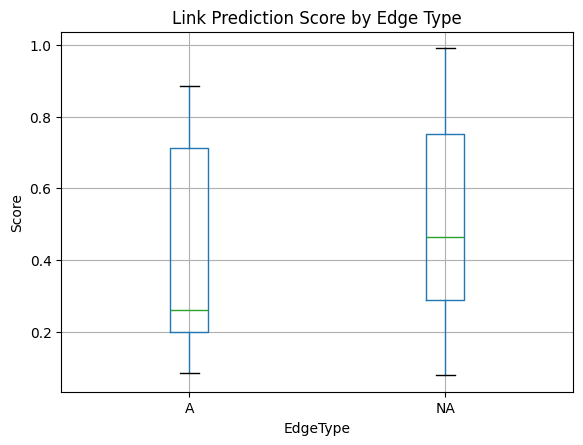

In [5]:
run(20)

Number of unique-orbit nodes: 3
Distinguishable edges: 0.005625
non-automorphic edges: 9
automorphic edges: 1591


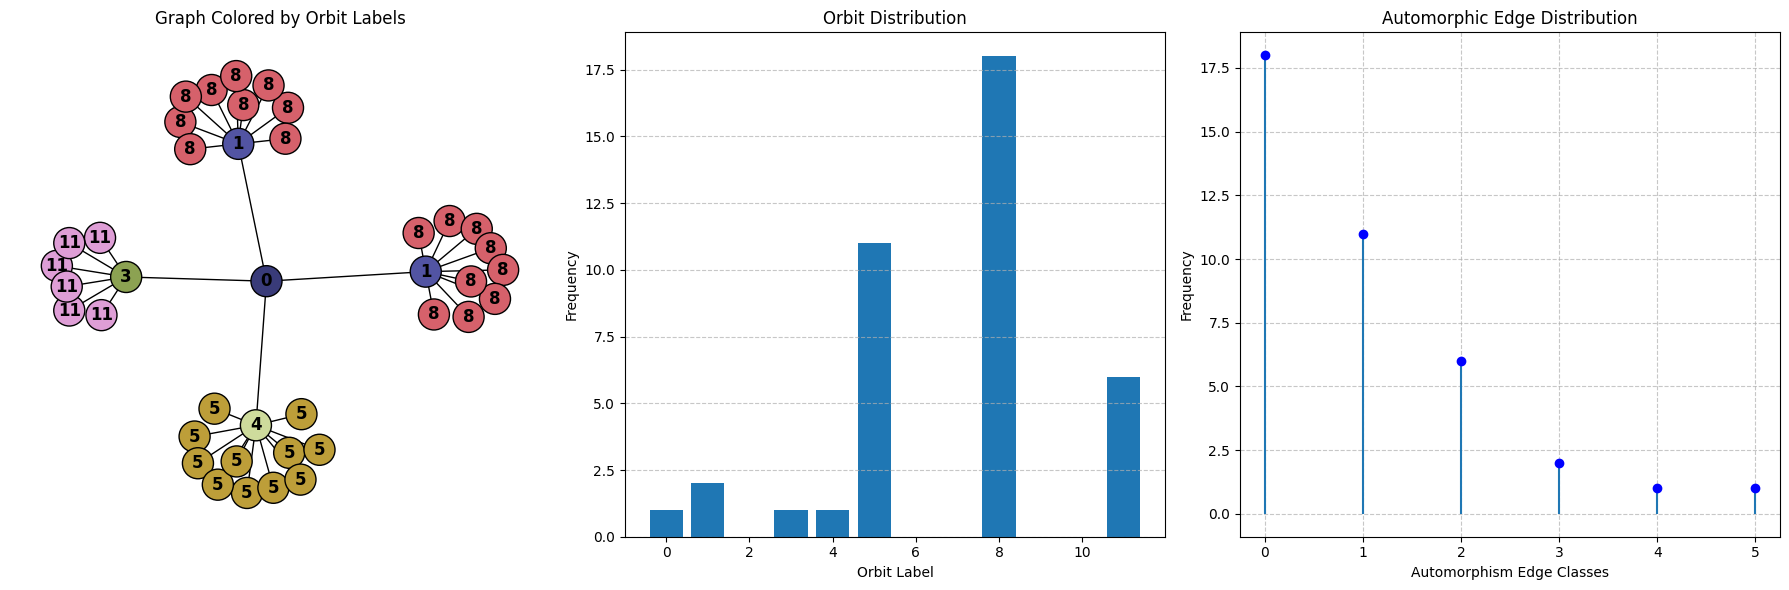

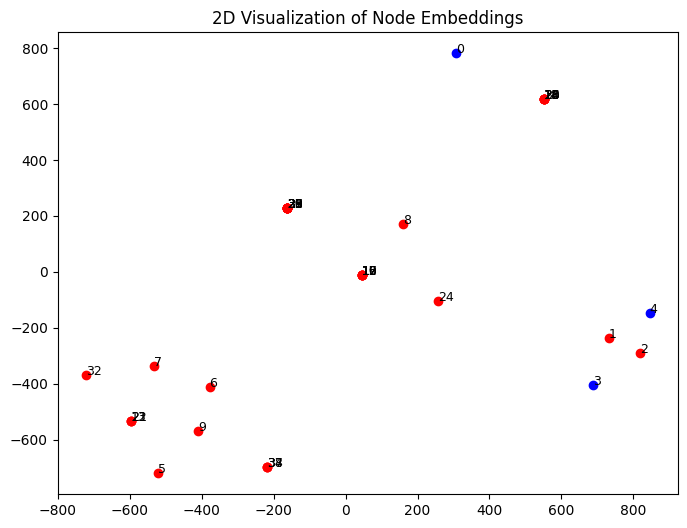

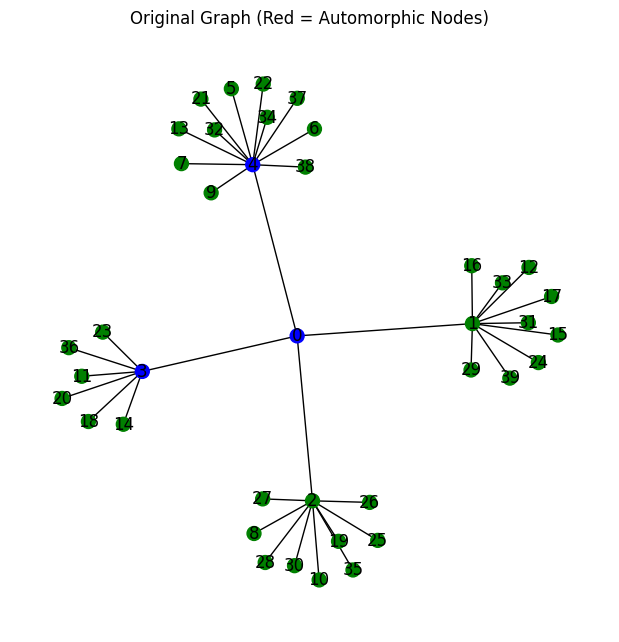

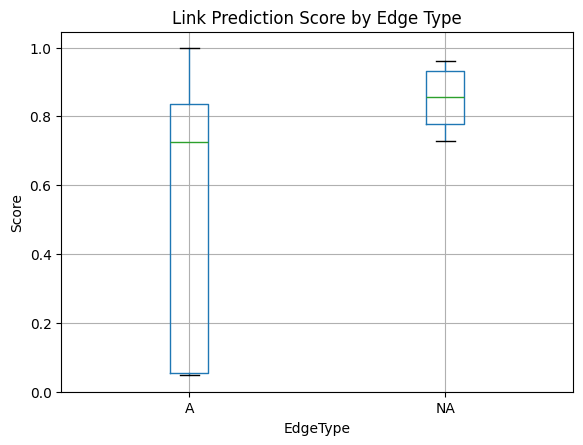

In [6]:
run(40)

Number of unique-orbit nodes: 46
Distinguishable edges: 0.8464
non-automorphic edges: 2116
automorphic edges: 384


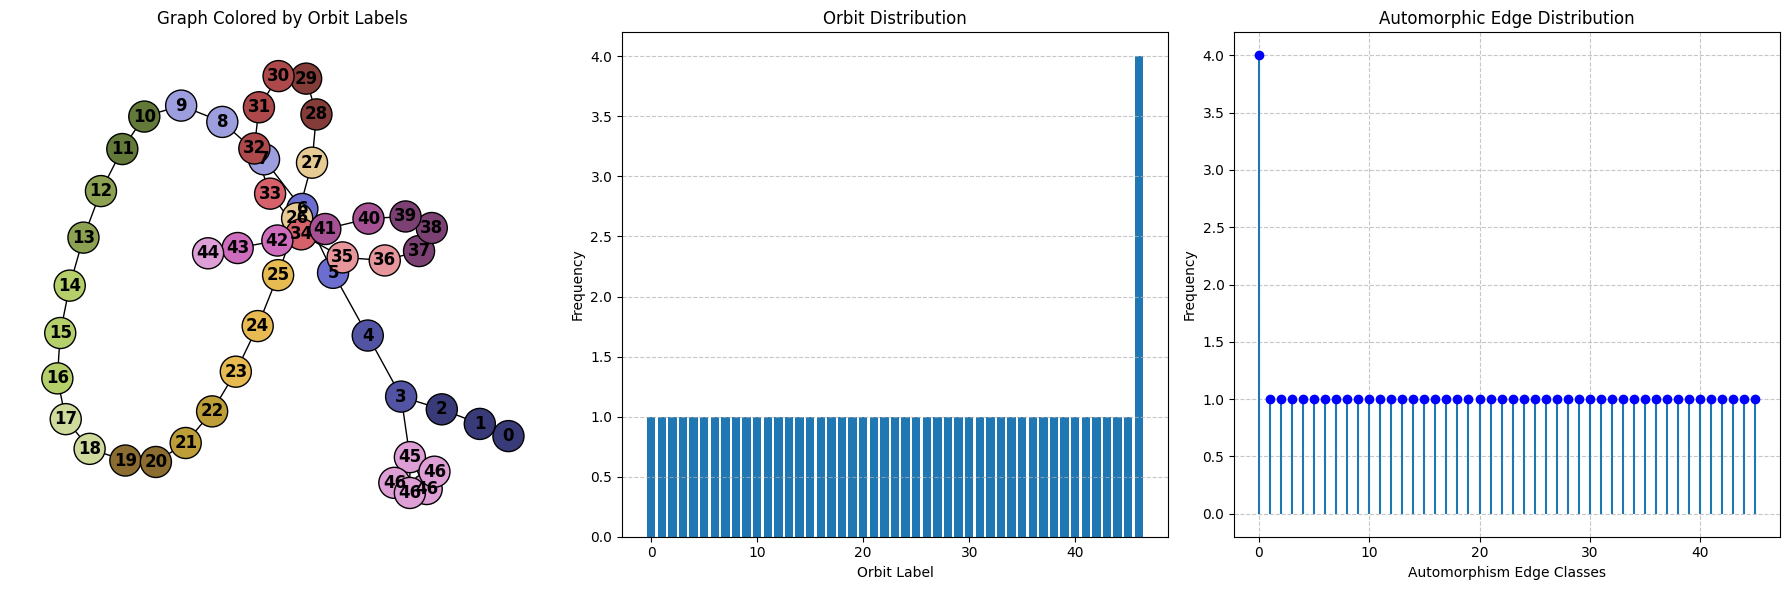

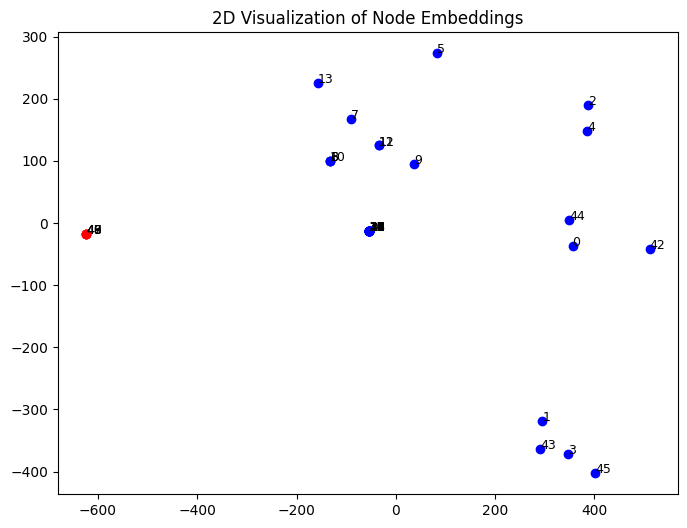

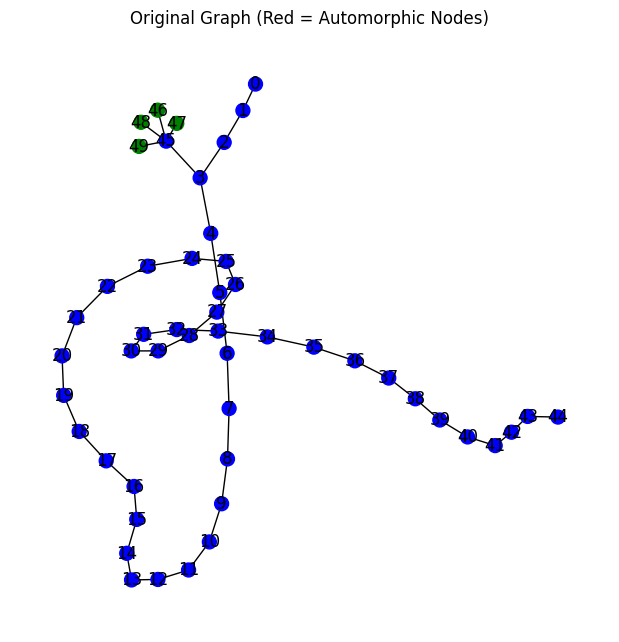

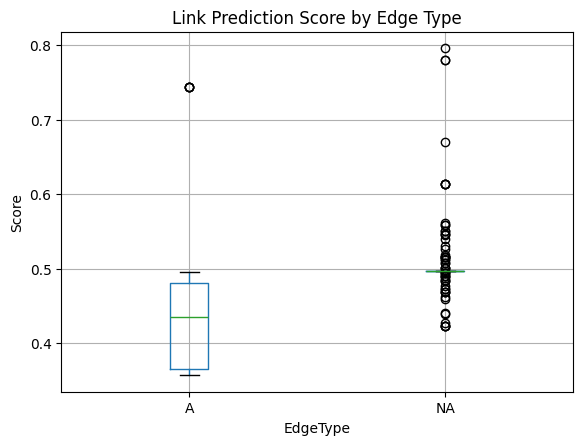

In [7]:
run(50)

Number of unique-orbit nodes: 53
Distinguishable edges: 0.7802777777777777
non-automorphic edges: 2809
automorphic edges: 791


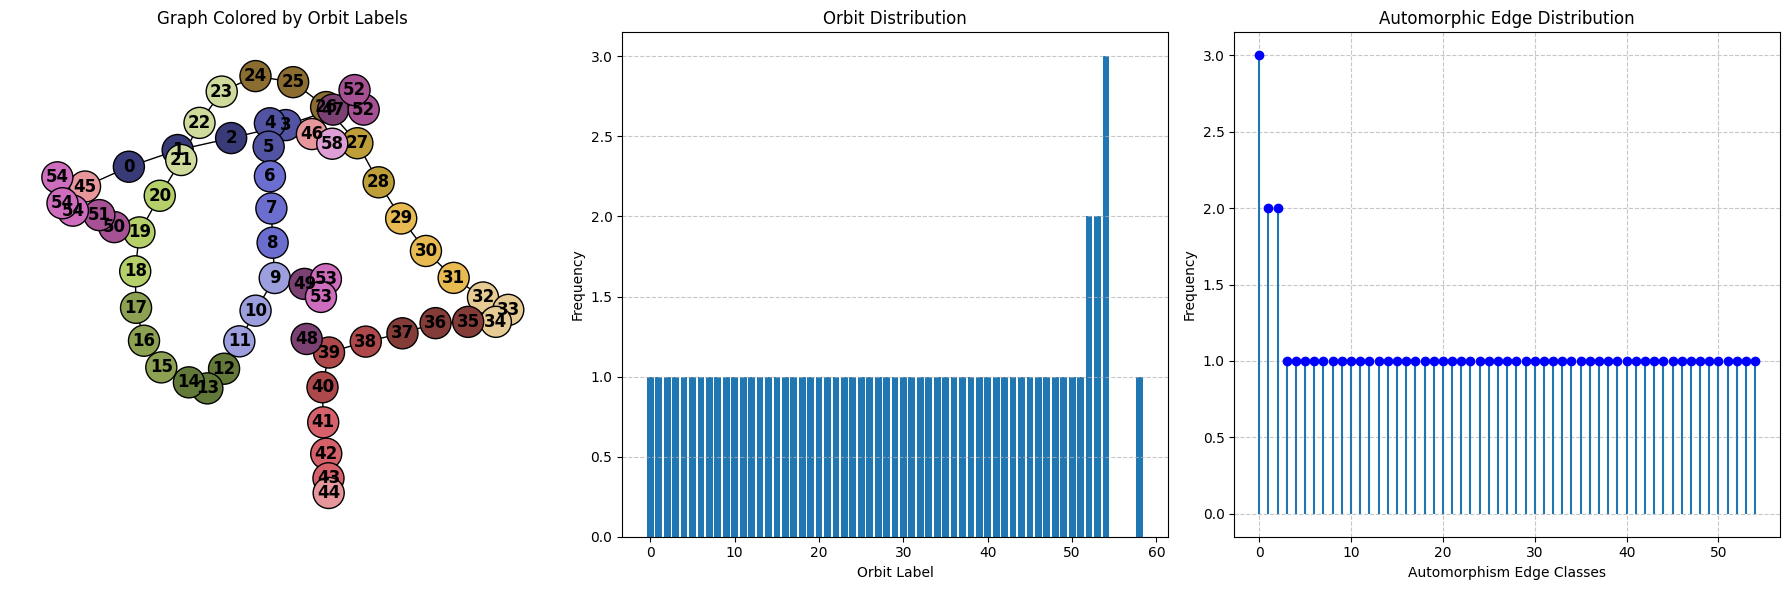

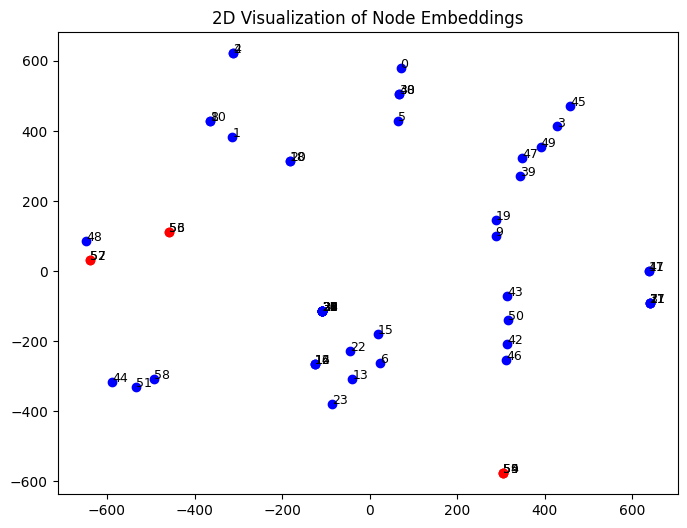

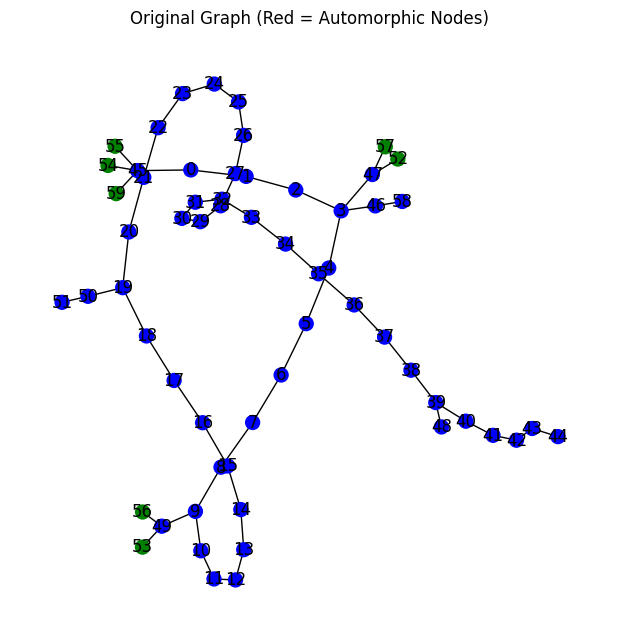

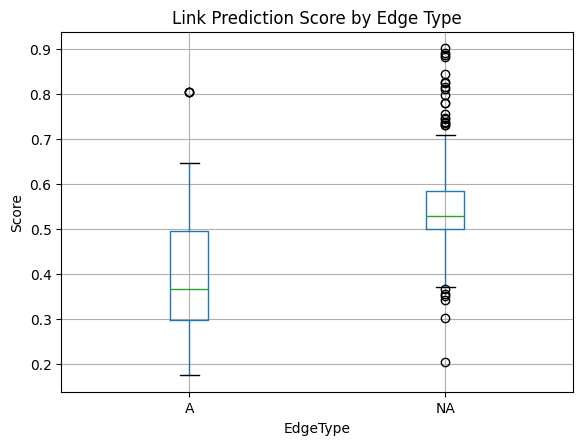

In [8]:
run(60)

Number of unique-orbit nodes: 81
Distinguishable edges: 0.6561
non-automorphic edges: 6561
automorphic edges: 3439


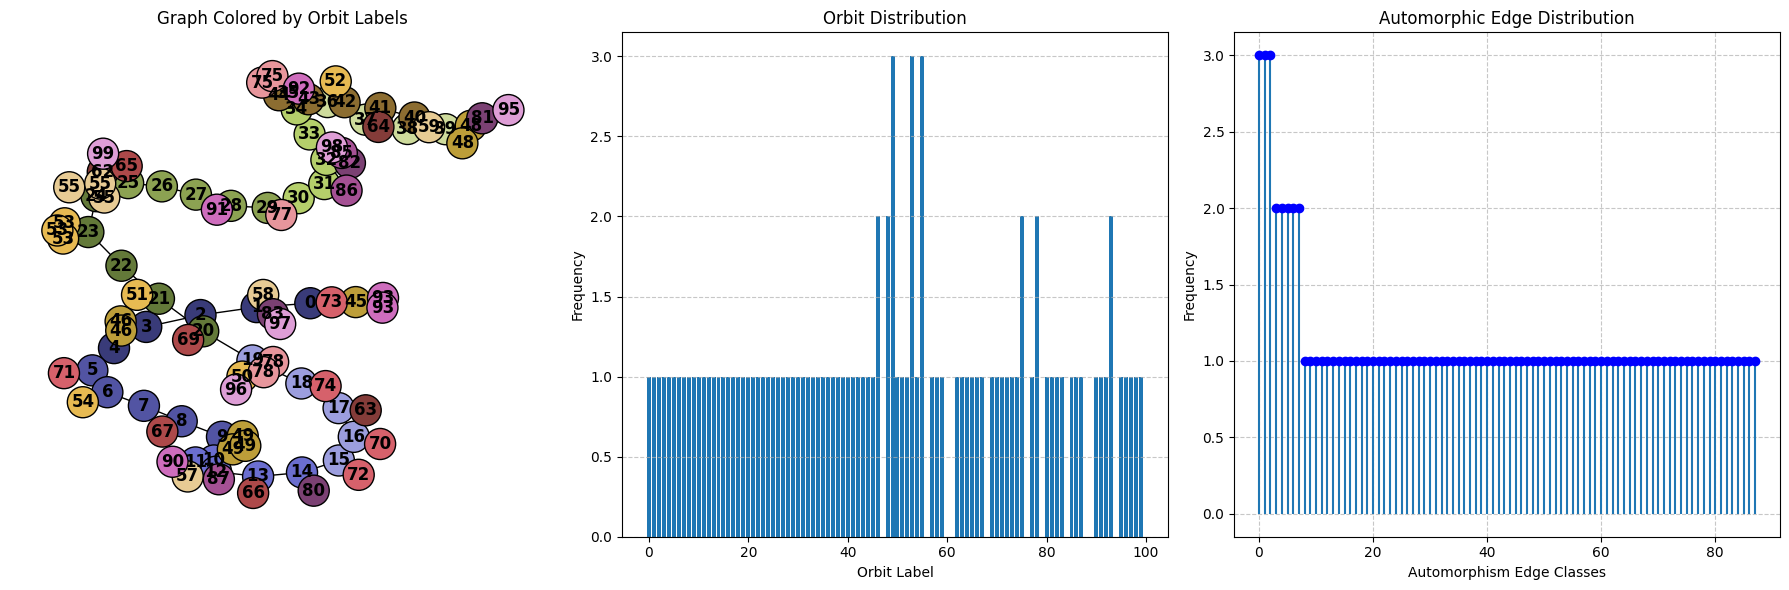

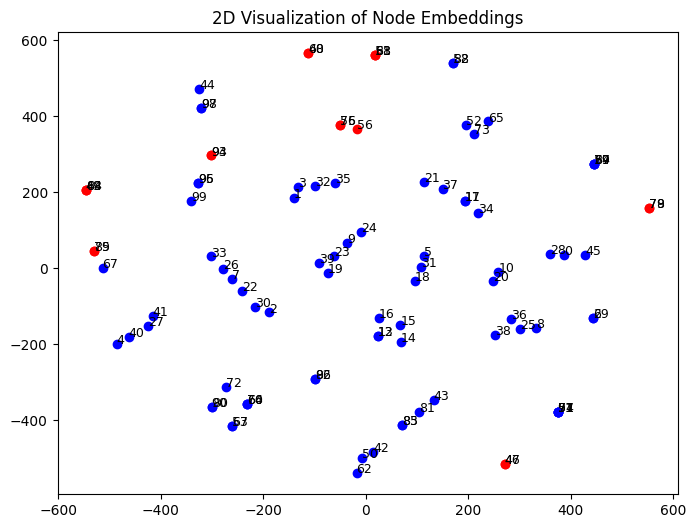

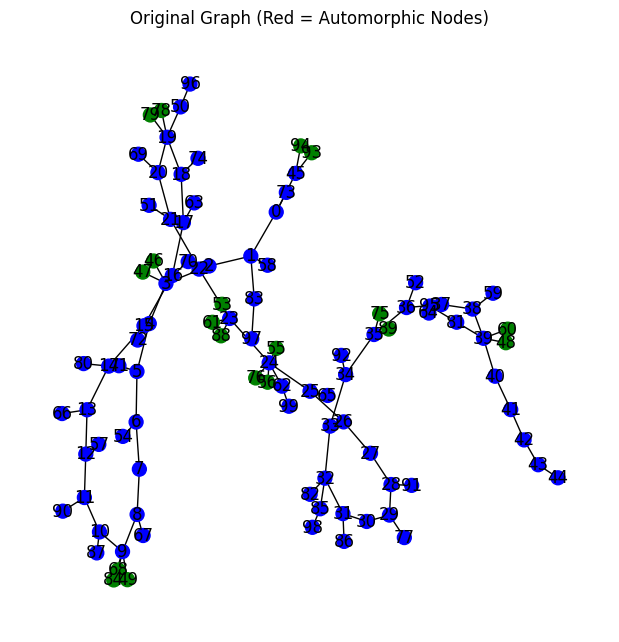

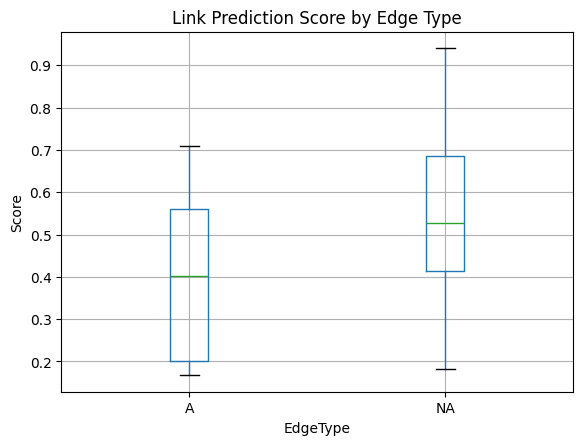

In [9]:
run(100)